In [1]:
import numpy as np # type: ignore

from PIL import Image

from matplotlib import cbook
import imageio

import sys
sys.path.append('./')
from code_plots import plot_cut_phase_diagram_dual
from code_load_data import get_all_data


figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/cuts_phase_diagram/XXXXX"

In [2]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

### Plots odd chains

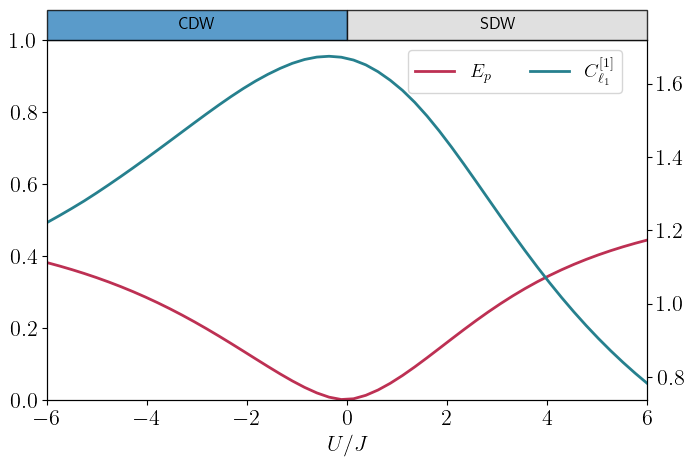

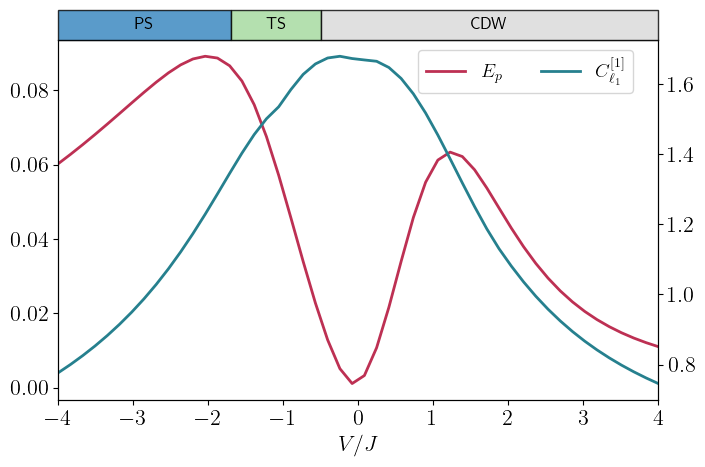

In [3]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
# import imageio
from scipy.ndimage import gaussian_filter

def plot_cut_phase_diagram(
    x_vals, y_vals,
    correlation_1, 
    coherence_1,
    target, x_label, y_labels, fname,
    title=None, phase_boundaries=None,
    fixed_axis="y", curve_labels=None,
    x_min=None, x_max=None,
    y_min=None, y_max=None, 
    left_limits = True
):
    """
    Plot 1D cuts of four 2D measures (two correlated, two coherent)
    with phase-color bands and masking for chosen x/y limits.
    """

    # ==== Handle limits and masks ====
    if x_min is None: x_min = np.min(x_vals)
    if x_max is None: x_max = np.max(x_vals)
    if y_min is None: y_min = np.min(y_vals)
    if y_max is None: y_max = np.max(y_vals)

    mask_x = (x_vals >= x_min) & (x_vals <= x_max)
    mask_y = (y_vals >= y_min) & (y_vals <= y_max)

    # Apply masks to all data
    x_vals_masked = x_vals[mask_x]
    y_vals_masked = y_vals[mask_y]

    correlation_1_masked = correlation_1[np.ix_(mask_x, mask_y)] if fixed_axis == "x" else correlation_1[np.ix_(mask_y, mask_x)]
    coherence_1_masked   = coherence_1[np.ix_(mask_x, mask_y)] if fixed_axis == "x" else coherence_1[np.ix_(mask_y, mask_x)]

    # ==== Outer figure ====
    fig_big = plt.figure(figsize=(8, 6))
    inner_pos = [0.12, 0.15, 0.75, 0.6]
    ax_left = fig_big.add_axes(inner_pos)
    ax_right = ax_left.twinx()

    def get_slice(measure, target, fixed_axis):
        if fixed_axis == "y":
            i_fixed = np.argmin(np.abs(y_vals_masked - target))
            return x_vals_masked, measure[:, i_fixed]
        elif fixed_axis == "x":
            i_fixed = np.argmin(np.abs(x_vals_masked - target))
            return y_vals_masked, measure[i_fixed, :]

    # ==== Plot correlation (left y-axis) ====
    x, y1 = get_slice(correlation_1_masked, target, fixed_axis)
    ax_left.plot(x, y1, '-', color="#bd3053", alpha=1, linewidth=2, label=f"{curve_labels[0]}")

    if left_limits != True:
        ax_left.set_ylim(0.0, 1.0)

    # ==== Plot coherence (right y-axis) ====
    x, y3 = get_slice(coherence_1_masked, target, fixed_axis)
    ax_right.plot(x, y3, '-', color="#26808e", alpha=1, linewidth=2, label=f"{curve_labels[2]}")

    # ax_right.set_ylim(0.0, max(np.max(coherence_1_masked), np.max(coherence_2_masked)))

    ax_left.set_xlim(x_min, x_max)

    # ==== Phase band ABOVE plot ====
    if phase_boundaries:
        numeric_boundaries = [(val, name) for val, name in phase_boundaries if val is not None]
        numeric_boundaries = sorted(numeric_boundaries, key=lambda x: x[0])

        x_min_, x_max_ = ax_left.get_xlim()
        regions = [x_min_] + [b[0] for b in numeric_boundaries] + [x_max_]
        phase_names = [b[1] for b in phase_boundaries]

        colors = plt.cm.tab20c(np.linspace(0, 1, len(phase_names)))

        fig_big.canvas.draw()
        band_bottom = inner_pos[1] + inner_pos[3]
        band_height = 0.05

        for i, name in enumerate(phase_names):
            x0 = inner_pos[0] + (regions[i] - x_min_) / (x_max_ - x_min_) * inner_pos[2]
            x1 = inner_pos[0] + (regions[i+1] - x_min_) / (x_max_ - x_min_) * inner_pos[2]
            width = x1 - x0
            rect = Rectangle(
                (x0, band_bottom), width, band_height,
                transform=fig_big.transFigure,
                color=colors[i], alpha=0.8, ec="black", lw=1
            )
            fig_big.patches.append(rect)
            fig_big.text(
                x0 + width/2, band_bottom + band_height/2,
                name, ha="center", va="center",
                fontsize=12, weight="bold", color="black"
            )
    # ==== Labels and legend ====
    ax_left.set_xlabel(x_label, fontsize=16)
    
    if(y_labels != None):
        ax_left.set_ylabel(y_labels[0], fontsize=13, color='tab:red')
        ax_right.set_ylabel(y_labels[1], fontsize=13, color='tab:blue')

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    all_lines = lines_left + lines_right
    all_labels = labels_left + labels_right

    fig_big.legend(
        all_lines, all_labels,
        fontsize=14, loc="upper right",
        ncol=2, frameon=True,
        bbox_to_anchor=(0.85, 0.75)
        )

    if title:
        ax_left.set_title(title, fontsize=14)

    fig_big.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

N_Points = 50
L = 5
U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)

Q_2 = Q_2.T 
quantum_coherence_2 = quantum_coherence_2.T
E_p = E_p.T 
quantum_coherence_1 = quantum_coherence_1.T

x_vals = U_vals 
y_vals = V_vals 
'''
# for targets in V_vals:
targets = 0.0
plot_cut_phase_diagram_dual(
    x_vals, y_vals,
    E_p, Q_2,
    quantum_coherence_1, quantum_coherence_2,
    target=targets,
    x_label=r"$U/J$",
    y_labels=(r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_V_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(0.0, r"$\text{CDW}$"), (None, r"$\text{SDW}$")], 
    fixed_axis="y"
)
# for targets in U_vals:
targets = 1.5
plot_cut_phase_diagram_dual(
    x_vals, y_vals,
    E_p, Q_2,
    quantum_coherence_1, quantum_coherence_2,
    target=targets,
    x_label=r"$V/J$",
    y_labels=(r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_U_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(-0.5, r"$\text{PS}$"), (1.0, r"$\text{SDW}$"), (None, r"$\text{CDW}$")], 
    fixed_axis="x", 
    x_min=-2.0, x_max=4.0,
    y_min=None, y_max=None
)
'''
targets = 0.0
plot_cut_phase_diagram(
    x_vals, y_vals,
    E_p,
    quantum_coherence_1,
    target=targets,
    x_label=r"$U/J$",
    y_labels= None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_V_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(None, r"$\text{CDW}$"), (0.0, r"$\text{SDW}$")], 
    fixed_axis="y", 
    x_min=-6.0, x_max=6.0,
    y_min=None, y_max=None,
    left_limits = False)
targets = 0.0 

plot_cut_phase_diagram(
    x_vals, y_vals,
    E_p,
    quantum_coherence_1,
    target=targets,
    x_label=r"$V/J$",
    y_labels= None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_U_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(-0.5, r"$\text{PS}$"), (-1.7, r"$\text{TS}$"), (None, r"$\text{CDW}$")], 
    fixed_axis="x", 
    x_min=-4, x_max=4.0,
    y_min=None, y_max=None,
    left_limits = True)

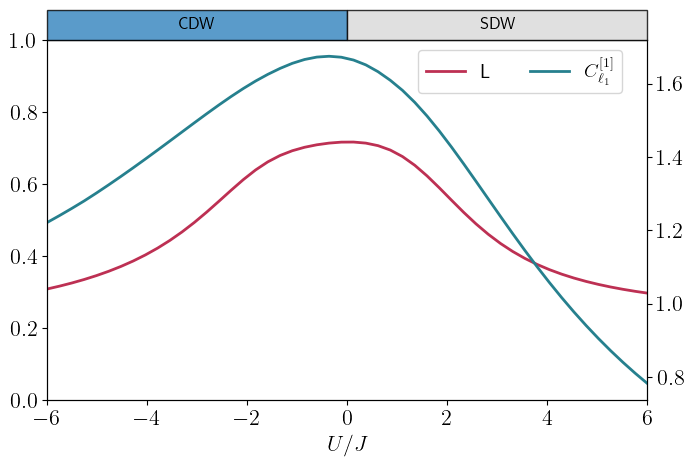

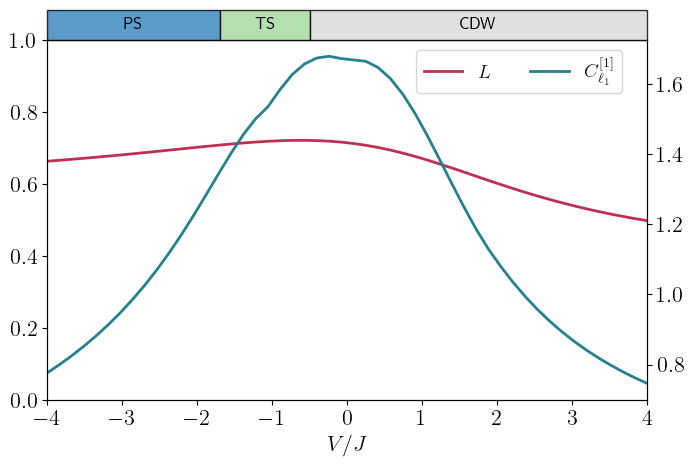

In [7]:
targets = 0.0
plot_cut_phase_diagram(
    x_vals, y_vals,
    avg_linear_entropy,
    quantum_coherence_1,
    target=targets,
    x_label=r"$U/J$",
    y_labels= None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_V_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["L", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(None, r"$\text{CDW}$"), (0.0, r"$\text{SDW}$")], 
    fixed_axis="y", 
    x_min=-6.0, x_max=6.0,
    y_min=None, y_max=None,
    left_limits = False)


targets = 0.0 
plot_cut_phase_diagram(
    x_vals, y_vals,
    avg_linear_entropy,
    quantum_coherence_1,
    target=targets,
    x_label=r"$V/J$",
    y_labels= None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_U_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$L$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(-0.5, r"$\text{PS}$"), (-1.7, r"$\text{TS}$"), (None, r"$\text{CDW}$")], 
    fixed_axis="x", 
    x_min=-4, x_max=4.0,
    y_min=None, y_max=None,
    left_limits = False)

### Plots for even chains

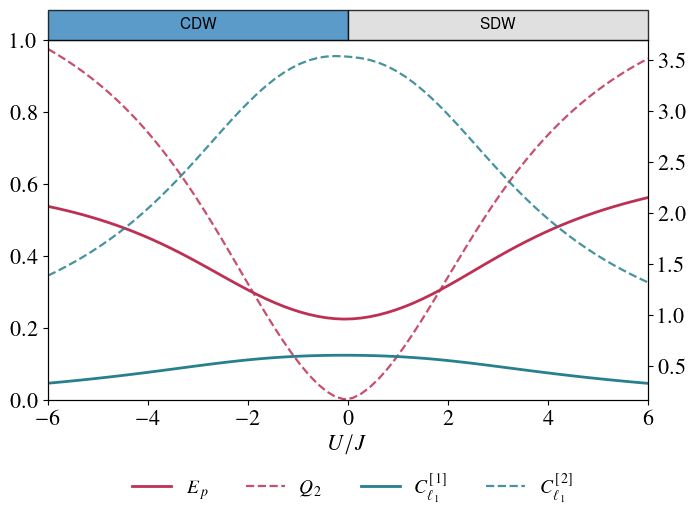

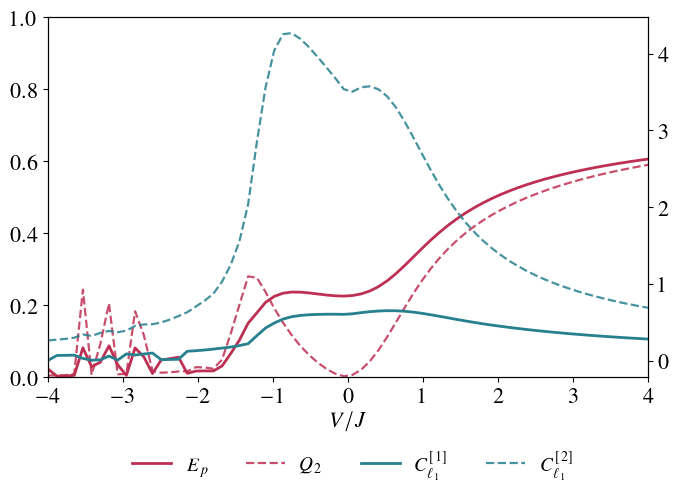

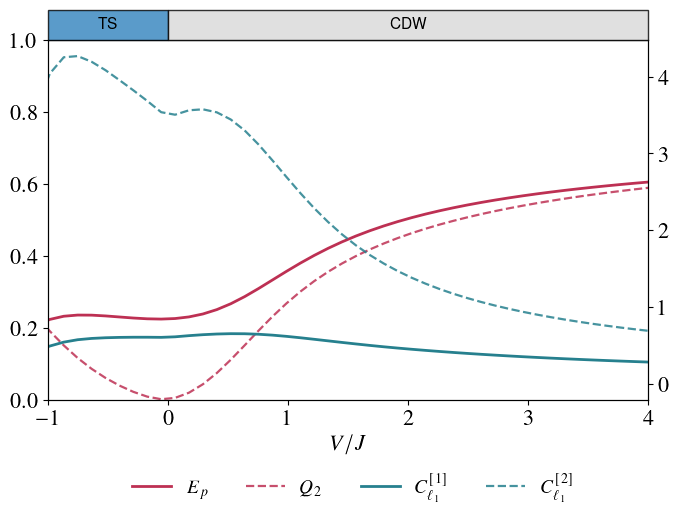

In [ ]:
N_Points = 70
L = 10
U_vals, V_vals, E_p, Q_2, quantum_coherence_1, quantum_coherence_2, avg_linear_entropy, E_GS, magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = get_all_data(results, model, exec, L, N_Points)

Q_2 = Q_2.T 
quantum_coherence_2 = quantum_coherence_2.T
E_p = E_p.T 
quantum_coherence_1 = quantum_coherence_1.T

x_vals = U_vals 
y_vals = V_vals 

# for targets in V_vals:
targets = 0.0
plot_cut_phase_diagram_dual(
    x_vals, y_vals,
    E_p, Q_2,
    quantum_coherence_1, quantum_coherence_2,
    target=targets,
    x_label=r"$U/J$",
    y_labels=None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_V_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(0.0, r"$\text{CDW}$"), (None, r"$\text{SDW}$")], 
    fixed_axis="y"
)

# for targets in U_vals:
targets = 0.0
plot_cut_phase_diagram_dual(
    x_vals, y_vals,
    E_p, Q_2,
    quantum_coherence_1, quantum_coherence_2,
    target=targets,
    x_label=r"$V/J$",
    y_labels=None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_U_target={targets}_NPoints={N_Points}.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    # phase_boundaries=[(-2.0, r"$\text{PS}$"), (-0.5, r"$\text{TS}$"), (1.0, r"$\text{SDW}$"), (None, r"$\text{CDW}$")], 
    fixed_axis="x", 
    x_min=-4.0, x_max=4.0,
    y_min=None, y_max=None
    )

plot_cut_phase_diagram_dual(
    x_vals, y_vals,
    E_p, Q_2,
    quantum_coherence_1, quantum_coherence_2,
    target=targets,
    x_label=r"$V/J$",
    y_labels= None, # (r"Correlation", r"Coherence"),
    fname=fig_path.replace("XXXXX", f"cut_phase_diagram_L={L}_U_target={targets}_NPoints={N_Points}_limited.pdf"),
    # title="Cut of Correlation and Coherence Measures",
    curve_labels=["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"],
    phase_boundaries=[(None, r"$\text{TS}$"),  (0.0, r"$\text{CDW}$")], 
    fixed_axis="x", 
    x_min=-1.0, x_max=4.0,
    y_min=None, y_max=None
)

### GIF

In [ ]:
GIF = False
if(GIF):
    # Your original function, slightly modified
    def plot_cut_phase_diagram_dual_for_gif(
        x_vals, y_vals,
        correlation_1, correlation_2,
        coherence_1, coherence_2,
        target, x_label, y_labels,
        title=None, phase_boundaries=None,
        fixed_axis="y", curve_labels=None, 
    ) -> Figure:
        """
        Plot 1D cuts of four 2D measures (two correlated, two coherent)
        along either x or y, fixing the other axis, and returns the figure.
        """
        fig, ax_left = plt.subplots(figsize=(7, 5))
        ax_right = ax_left.twinx()
        # Prepare color scheme
        # Choose slicing axis
        def get_slice(measure, target, fixed_axis):
            if fixed_axis == "y":
                # Find the index in y_vals closest to the target
                i_fixed = np.argmin(np.abs(y_vals - target))
                return x_vals, measure[:, i_fixed]
            elif fixed_axis == "x":
                # Find the index in x_vals closest to the target
                i_fixed = np.argmin(np.abs(x_vals - target))
                return y_vals, measure[i_fixed, :]

        # Plot correlation curves (left y-axis)
        x, y1 = get_slice(correlation_1, target, fixed_axis)
        _, y2 = get_slice(correlation_2, target, fixed_axis)
        
        ax_left.plot(x, y1, '-', color="#d9466a", alpha=0.6, linewidth=2, label=f"{curve_labels[0]}")
        ax_left.plot(x, y2, '--', color="#d9466a", alpha=0.8, linewidth=1.6, label=f"{curve_labels[1]}")
        
        ax_left.set_ylim(0.0, 1.0)
        ax_left.set_ylabel(y_labels[0], fontsize=13, color="#d9466a") # Added y-label

        # Plot coherence curves (right y-axis)
        x, y3 = get_slice(coherence_1, target, fixed_axis)
        _, y4 = get_slice(coherence_2, target, fixed_axis)
        ax_right.plot(x, y3, '-', color="#26808e", alpha=0.5, linewidth=2, label=f"{curve_labels[2]}")
        ax_right.plot(x, y4, '--', color="#26808e", alpha=0.8, linewidth=1.6, label=f"{curve_labels[3]}")

        ax_right.set_ylim(0.0, 6.0)
        ax_right.set_ylabel(y_labels[1], fontsize=13, color="#26808e") # Added y-label

        # Phase boundaries
        if phase_boundaries:
            numeric_boundaries = [(val, name) for val, name in phase_boundaries if val is not None]
            numeric_boundaries = sorted(numeric_boundaries, key=lambda x: x[0])
            for x_phase, _ in numeric_boundaries:
                ax_left.axvline(x=x_phase, color="#a62828", linestyle="--", linewidth=0.8)

            x_min, x_max = ax_left.get_xlim()
            regions = [x_min] + [b[0] for b in numeric_boundaries] + [x_max]
            # This assumes phase_boundaries are given in order for the text to make sense
            phase_names = [b[1] for b in phase_boundaries if b[0] is not None]

            for i in range(len(phase_names)):
                x_mid = 0.5 * (regions[i] + regions[i+1])
                ax_left.text(x_mid, ax_left.get_ylim()[1]*0.9, phase_names[i],
                            ha="center", va="top", fontsize=10, weight="bold",
                            bbox=dict(boxstyle="round,pad=0.3",
                                    ec="#9332a7", fc="#9332a7", alpha=0.7))

        # Labels and legend
        ax_left.set_xlabel(x_label, fontsize=13)

        # Set the title, defaulting to a dynamic one if none is provided
        if title is None:
            title = f"$V/J = {target:.2f}$"
        fig.suptitle(title, fontsize=18, weight="bold")

        # Merge legends
        lines_left, labels_left = ax_left.get_legend_handles_labels()
        lines_right, labels_right = ax_right.get_legend_handles_labels()
        ax_left.legend(lines_left + lines_right,
                    labels_left + labels_right,
                    fontsize=16, loc="upper right", ncol=2)

        # plt.tight_layout(rect=[0, 0, 1, 0.95])
        return fig

    figures = []
    gif_images = []
    # Define your static parameters
    x_label = r"$U/J$"
    y_labels = (r"Correlation", r"Coherence")
    curve_labels = ["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"]
    output_gif_name = f"{figures_path}/{model}_{exec}/cut_phase_diagram_various_V_L={L}.gif"
    print("Generating frames...")


    # 1. Iterate over targets (V_vals) to generate figures
    for target_v in V_vals:
        # Generate the title dynamically using an f-string
        dynamic_title = f"$V/J = {target_v:.2f}$"
        
        fig = plot_cut_phase_diagram_dual_for_gif(
            x_vals, y_vals,
            E_p, Q_2,
            quantum_coherence_1, quantum_coherence_2,
            target=target_v,
            x_label=x_label,
            y_labels=y_labels,
            title=dynamic_title,
            curve_labels=curve_labels,
            fixed_axis="y"
        )
        figures.append(fig)

        # 2. Capture the figure as an image array
        fig.canvas.draw()
        image_array = np.array(fig.canvas.renderer.buffer_rgba())

        # 3. Convert the array to a Pillow Image
        img = Image.fromarray(image_array)
        gif_images.append(img)
        
        # Close the figure to free memory
        plt.close(fig)
    # 4. Save the list of images as an animated GIF
    if gif_images:
        # The first frame is saved, and subsequent frames are appended
        gif_images[0].save(
            output_gif_name,
            save_all=True,
            append_images=gif_images[1:],
            optimize=False,
            duration=300,  # Milliseconds per frame (e.g., 300ms = 3.3 FPS)
            loop=0
        )
        print(f"Successfully created GIF: {output_gif_name}")
    else:
        print("No frames were generated.")
    

    figures = []
    gif_images = []
    # Define your static parameters
    x_label = r"$U/J$"
    y_labels = (r"Correlation", r"Coherence")
    curve_labels = ["$E_p$", "$Q_2$", "$C_{\\ell_1}^{[1]}$", "$C_{\\ell_1}^{[2]}$"]
    output_gif_name = f"{figures_path}/{model}_{exec}/cut_phase_diagram_various_U_L={L}.gif"
    print("Generating frames...")

    # 1. Iterate over targets (V_vals) to generate figures
    for target_u in U_vals:
        # Generate the title dynamically using an f-string
        dynamic_title = f"$U/J = {target_u:.2f}$"
        
        fig = plot_cut_phase_diagram_dual_for_gif(
            x_vals, y_vals,
            E_p, Q_2,
            quantum_coherence_1, quantum_coherence_2,
            target=target_u,
            x_label=x_label,
            y_labels=y_labels,
            title=dynamic_title,
            curve_labels=curve_labels,
            fixed_axis="x"
        )
        figures.append(fig)

        # 2. Capture the figure as an image array
        fig.canvas.draw()
        image_array = np.array(fig.canvas.renderer.buffer_rgba())

        # 3. Convert the array to a Pillow Image
        img = Image.fromarray(image_array)
        gif_images.append(img)
        
        # Close the figure to free memory
        plt.close(fig)
    # 4. Save the list of images as an animated GIF
    if gif_images:
        # The first frame is saved, and subsequent frames are appended
        gif_images[0].save(
            output_gif_name,
            save_all=True,
            append_images=gif_images[1:],
            optimize=False,
            duration=300,  # Milliseconds per frame (e.g., 300ms = 3.3 FPS)
            loop=0
        )
        print(f"Successfully created GIF: {output_gif_name}")
    else:
        print("No frames were generated.")